# SkinGen — generating rare skin lesion images with a conditional GAN

Rare skin cancers are the ones a classifier is most likely to miss, simply because there are
so few examples to learn from. In HAM10000 the largest class has roughly **6x** as many images
as the smallest even after the common classes are capped, and about **58x** in the full dataset.

This notebook trains a **conditional GAN** on HAM10000, uses it to synthesise extra images of
the rare classes, and then asks a direct question: **does a classifier trained on real +
synthetic images detect rare lesions better than the same classifier trained on real images
alone?**

| Step | What happens |
|---|---|
| 1 | Load HAM10000 (7 lesion types) at 32x32 |
| 2 | Train a conditional DCGAN over all 7 classes |
| 3 | Generate synthetic images for the rare classes |
| 4 | Train the same CNN three times: real only, real + classical augmentation, real + CGAN |
| 5 | Compare per-class recall on an untouched real test set |

The classical arm matters: flips and rotations are almost free, so synthetic images have to beat
**them**, not just beat doing nothing.

Everything below is a real run. The test set is **real images only** — synthetic data is used
for training and never for scoring.


In [1]:
import json
import time

import torch

import augment
import data
import plots
import train_cgan
import train_classifier
from models import pick_device

ASSETS = data.CACHE.parent.parent / "assets"
ASSETS.mkdir(exist_ok=True)

DEVICE = pick_device()
torch.manual_seed(42)

print("torch", torch.__version__)
print("device", DEVICE)


torch 2.13.0
device mps


## 1. The data and the imbalance

The subset caps the common classes at 700 images and keeps every image of the rare ones, so
the imbalance is reduced but still very much present. Data comes from the `marmal88/skin_cancer`
mirror of HAM10000, which needs no Kaggle credentials and is cached after the first run.


In [2]:
payload = data.load_data()
images = data.to_float(payload["images"], image_size=32)
labels = payload["labels"]
n_classes = len(payload["classes"])

counts = data.class_counts(labels)
print(f"{len(labels)} images at {tuple(images.shape[2:])}, {n_classes} classes\n")
for name, count in sorted(counts.items(), key=lambda item: -item[1]):
    marker = "  <- rare" if name in data.RARE_CLASSES else ""
    print(f"  {name:<6} {count:>4}{marker}")

print(f"\nimbalance ratio: {max(counts.values()) / min(counts.values()):.1f}x")


3148 images at (32, 32), 7 classes

  bkl     700
  mel     700
  nv      700
  bcc     487
  akiec   315  <- rare
  vasc    136  <- rare
  df      110  <- rare

imbalance ratio: 6.4x


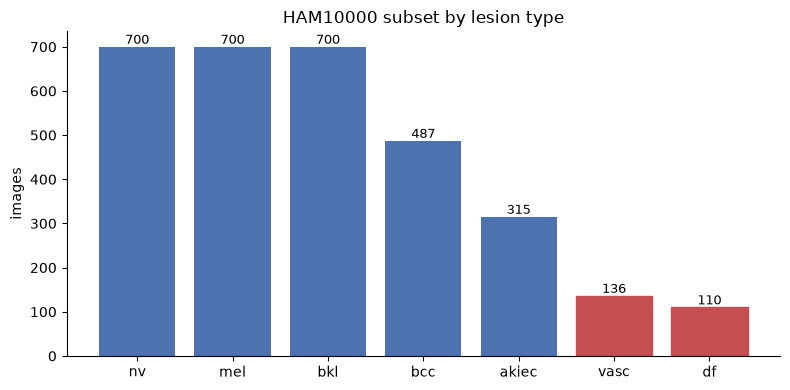

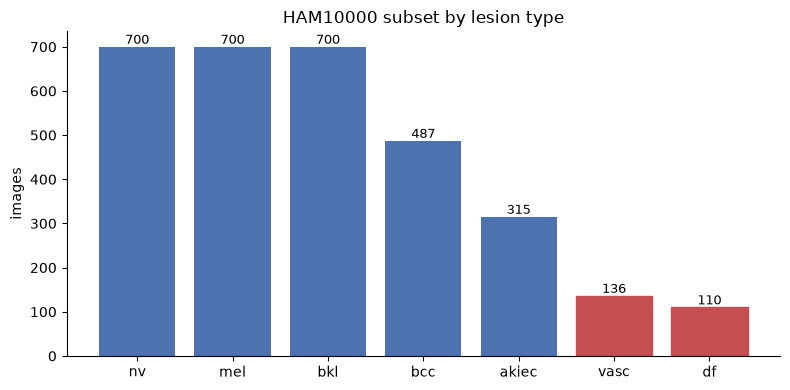

In [3]:
figure = plots.plot_class_distribution(counts, save_path=ASSETS / "class_distribution.png")
figure


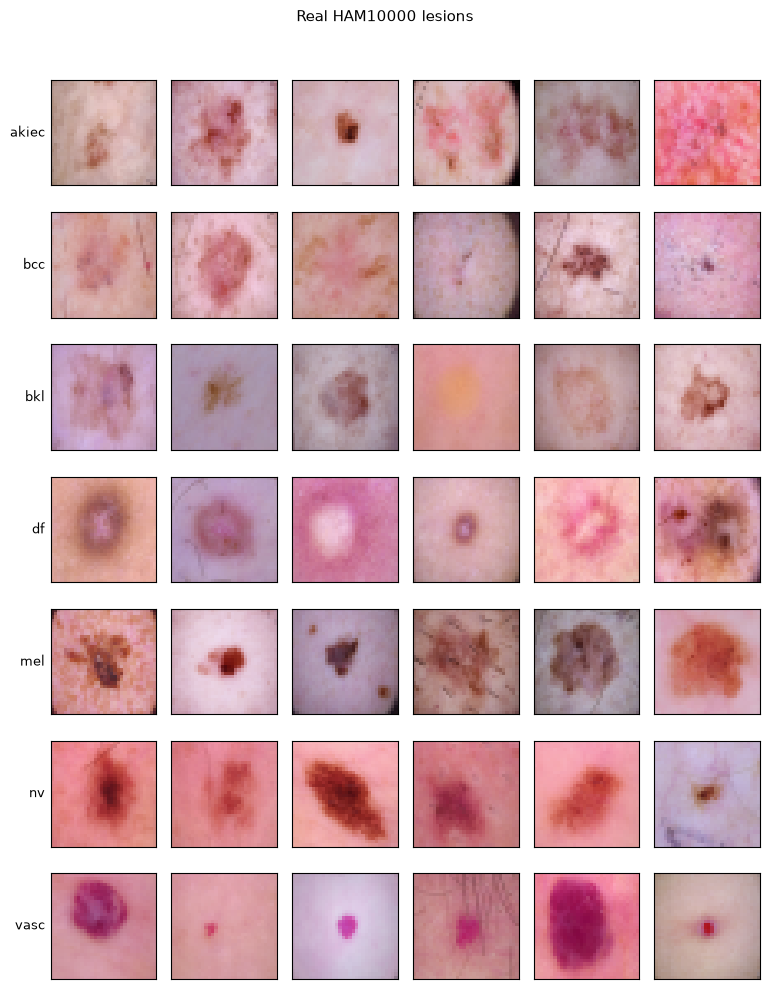

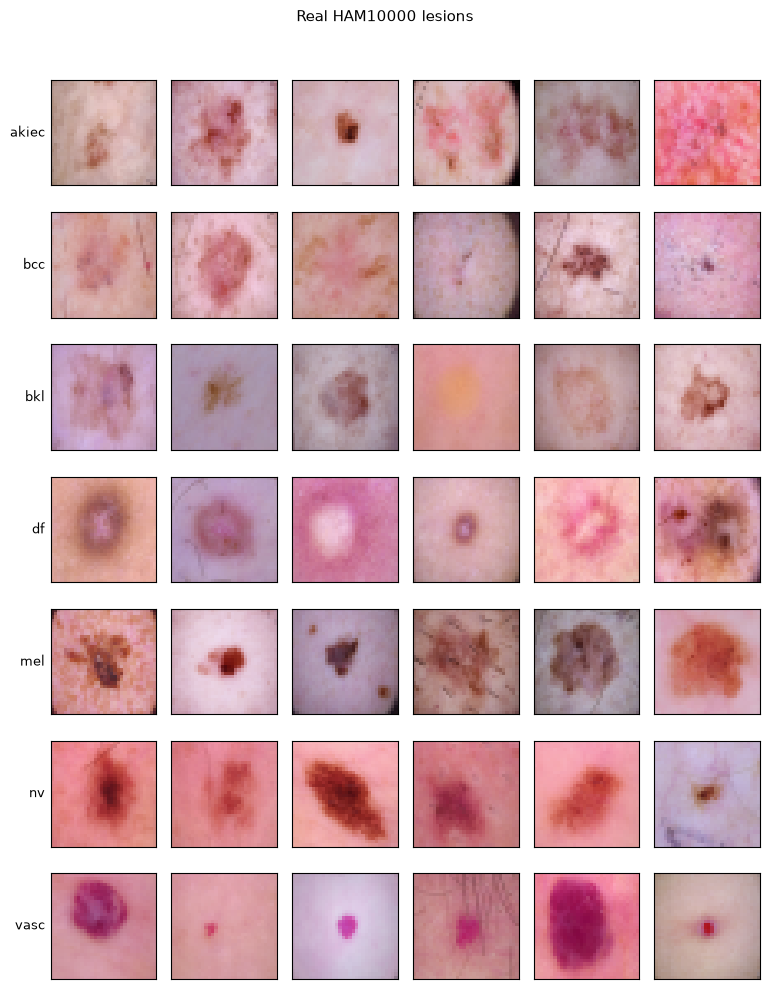

In [4]:
figure = plots.plot_samples(images, labels, "Real HAM10000 lesions",
                            save_path=ASSETS / "real_samples.png")
figure


## 2. Train the conditional GAN

The generator takes a noise vector plus a class label, so asking it for a specific lesion type
is just a matter of passing that label. The discriminator sees the label as an extra image
channel. Only the training split is used, so the GAN never sees a test image.

Two details are doing the heavy lifting, and both exist because the training set is small
(~2,500 images):

* **Differentiable augmentation** ([Zhao et al., 2020](https://arxiv.org/abs/2006.10738)) —
  colour, translation and cutout applied to **both** real and fake images before the
  discriminator sees them.
* **Spectral normalisation** on every discriminator convolution, which bounds its Lipschitz
  constant so it cannot simply memorise 2,500 images and stop producing useful gradient.
* **Mode-seeking regularisation** ([Mao et al., 2019](https://arxiv.org/abs/1903.05628)) — two
  noise vectors are pushed through the generator with the same label, and the generator is
  rewarded for the two images being far apart relative to the distance between the vectors.

Without the first two the discriminator wins outright: `d_loss` collapses toward 0.5, `g_loss`
climbs past 5, and training never recovers. The third is what stops the generator from ignoring
its noise vector — see the README for the full debugging story, including why the more obvious
fix (a minibatch-stddev layer in the discriminator) does *not* work here.


In [5]:
train_index, test_index = data.stratified_split(labels, test_fraction=0.2, seed=42)

X_train, y_train = images[train_index], labels[train_index]
X_test, y_test = images[test_index], labels[test_index]

print(f"train {len(X_train)}   test {len(X_test)}")
print("test counts:", data.class_counts(y_test))


train 2519   test 629
test counts: {'akiec': 63, 'bcc': 97, 'bkl': 140, 'df': 22, 'mel': 140, 'nv': 140, 'vasc': 27}


In [6]:
started = time.time()
generator, gan_history = train_cgan.train(
    X_train, y_train, n_classes=n_classes, epochs=300, batch_size=64,
    image_size=32, device=DEVICE
)

updates = (len(X_train) // 64) * 300
print(f"\nCGAN trained in {time.time() - started:.0f}s  ({updates:,} generator updates)")


/private/tmp/claude-501/-Users-anijesh-GSSOC-work-ML-CaPsule/6f8854f6-06ed-4b4c-8669-bb66c52eea2f/scratchpad/venv/lib/python3.11/site-packages/torch/nn/functional.py:5823: UserWarning: MPS: The constant padding of more than 3 dimensions is not currently supported natively. It uses View Ops default implementation to run. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/mps/operations/Pad.mm:567.)
  return torch._C._nn.pad(input, pad, mode, value)


epoch   1/300  d_loss 1.234  g_loss 0.988  diversity 0.2237  [8s]


epoch  25/300  d_loss 1.231  g_loss 1.146  [169s]


epoch  50/300  d_loss 1.214  g_loss 1.152  diversity 0.3404  [339s]


epoch  75/300  d_loss 1.179  g_loss 1.167  [505s]


...

epoch 225/300  d_loss 0.877  g_loss 1.542  [1598s]


epoch 250/300  d_loss 0.783  g_loss 1.626  diversity 0.3340  [1776s]


epoch 275/300  d_loss 0.755  g_loss 1.697  [1947s]


epoch 300/300  d_loss 0.718  g_loss 1.705  diversity 0.4049  [2111s]



CGAN trained in 4807s  (11,700 generator updates)


The two panels below are the whole lesson of this project. **Losses alone cannot tell you a GAN
is working.** Earlier attempts here read only the losses, saw them behaving, and shipped a
generator that was emitting a single prototype per class. The right-hand panel is the check
that catches it: take several samples of the same class and measure how much they differ,
against the same measurement on real images.


real images       within-class pixel std 0.2386
generated (final) within-class pixel std 0.4049  (170% of real)


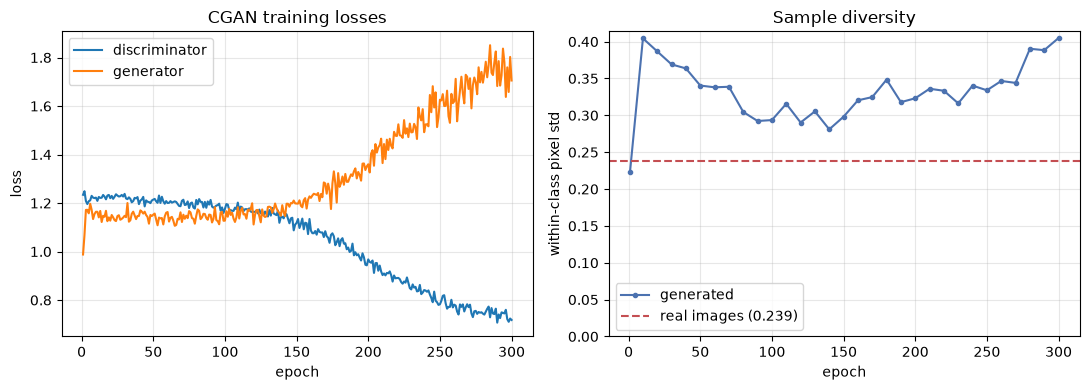

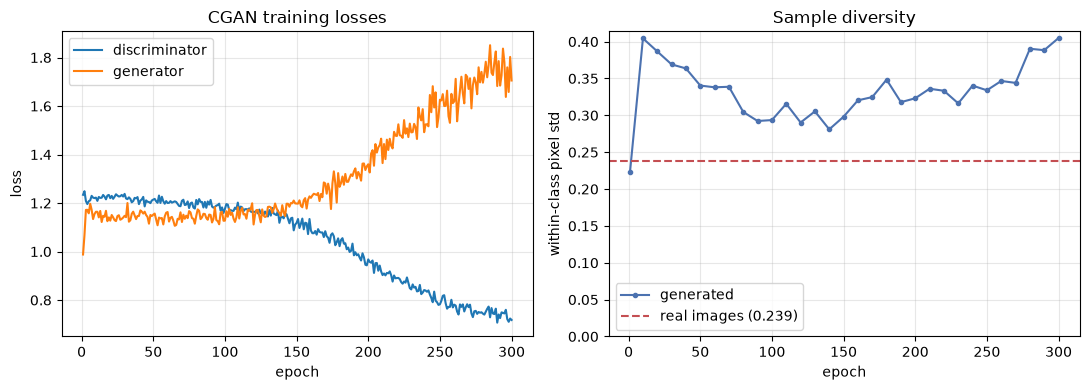

In [7]:
reference = train_cgan.real_diversity(X_train, y_train, n_classes)
figure = plots.plot_gan_losses(gan_history, real_diversity=reference,
                               save_path=ASSETS / "cgan_losses.png")

print(f"real images       within-class pixel std {reference:.4f}")
print(f"generated (final) within-class pixel std {gan_history[-1]['diversity']:.4f}  "
      f"({gan_history[-1]['diversity'] / reference:.0%} of real)")
figure


## 3. What the generator produces

One row per lesion type, sampled by conditioning on that label.


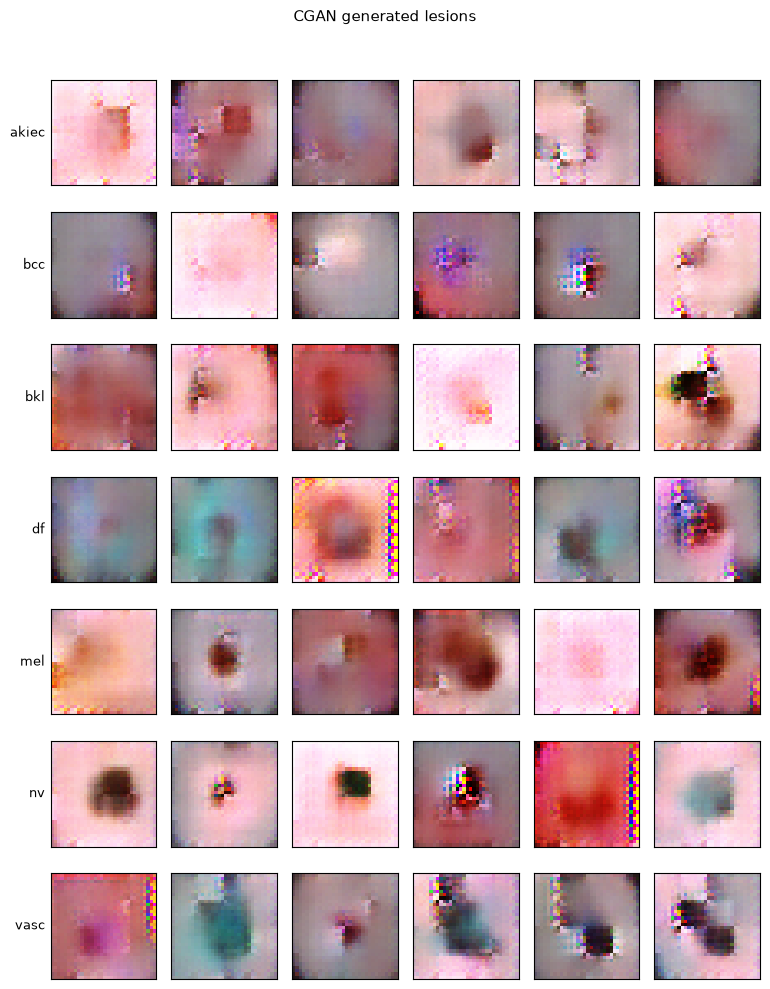

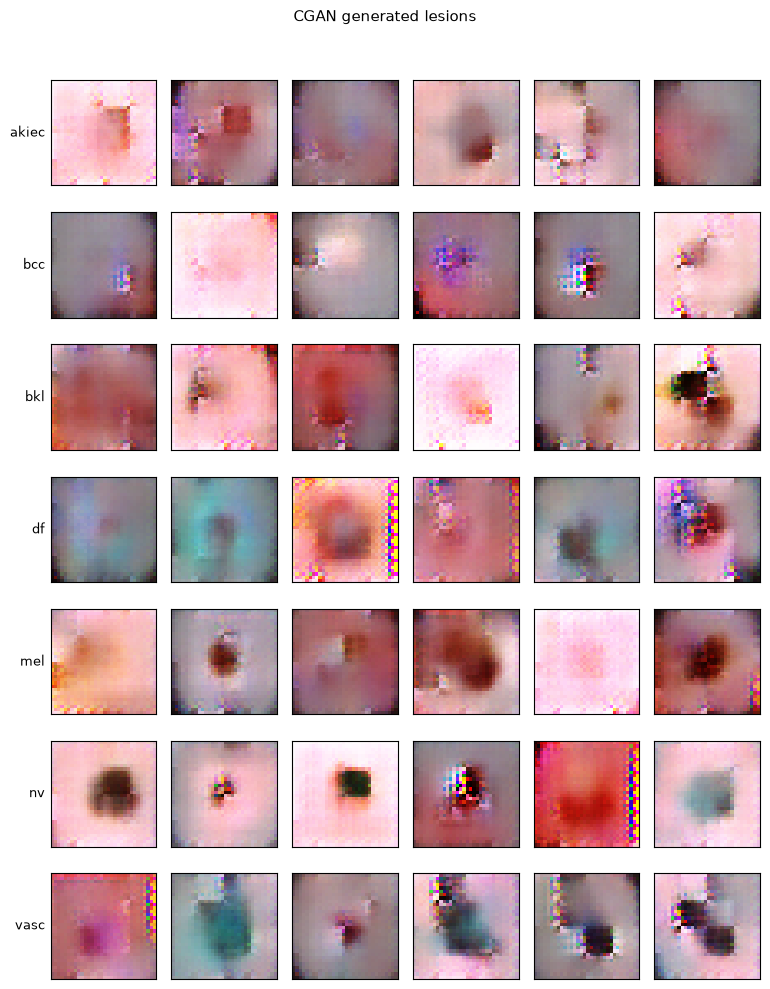

In [8]:
sample_labels = torch.arange(n_classes).repeat_interleave(6)
sample_images = train_cgan.generate(generator, sample_labels, device=DEVICE)

figure = plots.plot_samples(sample_images, sample_labels, "CGAN generated lesions",
                            save_path=ASSETS / "generated_samples.png")
figure


In [9]:
train_cgan.CHECKPOINT.parent.mkdir(parents=True, exist_ok=True)
torch.save({"generator": generator.state_dict(), "history": gan_history},
           train_cgan.CHECKPOINT)
print(f"generator saved to {train_cgan.CHECKPOINT}")


generator saved to /Users/anijesh/GSSOC_work/ML-CaPsule/SkinGen_CGAN_Skin_Cancer/cache/cgan.pt


At 32x32 these are coarse: colour, lesion shape and surrounding skin tone are what carry
through, not fine texture. The question is whether that is already enough to help a classifier.


## 4. Does the synthetic data help?

The same CNN is trained under identical settings for each arm. The only difference is what gets
added to the rare classes: nothing, classical augmentation (flips, rotations, brightness), or
CGAN samples. Both augmented runs add the **same number** of images, so the comparison is fair.

Each arm is trained **three times with different seeds** and the metrics averaged. The test set
is only 629 images, so one seed moves accuracy by a couple of points on its own — without
repeats it is impossible to tell a real effect from run-to-run noise.


In [10]:
SEEDS = (42, 43, 44)

baseline = train_classifier.repeat(X_train, y_train, X_test, y_test, n_classes,
                                   seeds=SEEDS, epochs=15, device=DEVICE, verbose=False)

print(f"real only  ->  accuracy {baseline['accuracy']:.3f}   "
      f"macro F1 {baseline['macro_f1']:.3f}   "
      f"(per-seed accuracy {baseline['accuracy_spread'][0]:.3f}-"
      f"{baseline['accuracy_spread'][1]:.3f})")


real only  ->  accuracy 0.609   macro F1 0.548   (per-seed accuracy 0.596-0.618)


### Does the class label actually control what the generator draws?

Before using synthetic images as training data it is worth checking that they carry the label
they are stamped with. If the generator ignored the label, the augmented arm would be training
on mislabelled data — which would hurt, not help.

The test: show the **real-only** classifier a batch of generated images and see how often it
assigns them the class they were generated as. The honest comparison is that classifier's
recall on *real* images of the same class, not 100%.


In [11]:
probe_labels = torch.arange(n_classes).repeat_interleave(100)
probe_images = train_cgan.generate(generator, probe_labels, device=DEVICE)
probe_predictions = train_classifier.predict(baseline["model"], probe_images, device=DEVICE)

print(f"{'class':<7} {'agreement on fake':>18} {'recall on real':>16}")
print("-" * 43)
for class_id in range(n_classes):
    picked = probe_labels == class_id
    agreement = (probe_predictions[picked] == class_id).float().mean().item()
    print(f"{data.SHORT_NAMES[payload['classes'][class_id]]:<7} {agreement:>18.3f} "
          f"{baseline['per_class'][class_id]['recall']:>16.3f}")

overall = (probe_predictions == probe_labels).float().mean().item()
print("-" * 43)
print(f"{'overall':<7} {overall:>18.3f} {baseline['accuracy']:>16.3f}")
print(f"\nchance level would be {1 / n_classes:.3f}")


class    agreement on fake   recall on real
-------------------------------------------
akiec                0.040            0.381
bcc                  0.240            0.680
bkl                  0.130            0.538
df                   0.000            0.136
mel                  0.530            0.645
nv                   0.400            0.740
vasc                 0.590            0.765
-------------------------------------------
overall              0.276            0.609

chance level would be 0.143


In [12]:
TARGET_PER_RARE = 500

rare_ids = [payload["classes"].index(name) for name in data.CLASSES
            if data.SHORT_NAMES[name] in data.RARE_CLASSES]

extra_labels = []
for class_id in rare_ids:
    have = int((y_train == class_id).sum())
    needed = max(0, TARGET_PER_RARE - have)
    extra_labels.extend([class_id] * needed)
    print(f"{data.SHORT_NAMES[payload['classes'][class_id]]:<6} {have:>4} real "
          f"-> generating {needed}")

extra_labels = torch.tensor(extra_labels)
extra_images = train_cgan.generate(generator, extra_labels, device=DEVICE)

X_gan = torch.cat([X_train, extra_images])
y_gan = torch.cat([y_train, extra_labels])

classical_parts, classical_labels = [], []
for class_id in rare_ids:
    pool = X_train[y_train == class_id]
    needed = int((extra_labels == class_id).sum())
    if needed:
        classical_parts.append(augment.classical_augment(pool, needed, seed=class_id))
        classical_labels.extend([class_id] * needed)

X_classical = torch.cat([X_train] + classical_parts)
y_classical = torch.cat([y_train, torch.tensor(classical_labels)])

print(f"\nreal only      {len(X_train)} images")
print(f"real + flips   {len(X_classical)} images")
print(f"real + CGAN    {len(X_gan)} images")


akiec   252 real -> generating 248
df       88 real -> generating 412
vasc    109 real -> generating 391



real only      2519 images
real + flips   3570 images
real + CGAN    3570 images


In [13]:
classical = train_classifier.repeat(X_classical, y_classical, X_test, y_test, n_classes,
                                    seeds=SEEDS, epochs=15, device=DEVICE, verbose=False)
print(f"real + flips ->  accuracy {classical['accuracy']:.3f}   "
      f"macro F1 {classical['macro_f1']:.3f}   "
      f"(per-seed accuracy {classical['accuracy_spread'][0]:.3f}-"
      f"{classical['accuracy_spread'][1]:.3f})")

augmented = train_classifier.repeat(X_gan, y_gan, X_test, y_test, n_classes,
                                    seeds=SEEDS, epochs=15, device=DEVICE, verbose=False)
print(f"real + CGAN  ->  accuracy {augmented['accuracy']:.3f}   "
      f"macro F1 {augmented['macro_f1']:.3f}   "
      f"(per-seed accuracy {augmented['accuracy_spread'][0]:.3f}-"
      f"{augmented['accuracy_spread'][1]:.3f})")

arms = {"real only": baseline, "real + flips": classical, "real + CGAN": augmented}


real + flips ->  accuracy 0.553   macro F1 0.528   (per-seed accuracy 0.509-0.576)


real + CGAN  ->  accuracy 0.580   macro F1 0.528   (per-seed accuracy 0.517-0.625)


## 5. Results

Per-class recall on the held-out **real** test set. Rare classes are marked `*` — they are the
ones the synthetic data was generated for, so they are where any effect should show up.


In [14]:
header = f"{'class':<7} {'support':>8}" + "".join(f"{arm:>14}" for arm in arms)
print(header)
print("-" * len(header))

for class_id in range(n_classes):
    short = data.SHORT_NAMES[payload["classes"][class_id]]
    flag = " *" if short in data.RARE_CLASSES else ""
    row = f"{short + flag:<7} {baseline['per_class'][class_id]['support']:>8}"
    row += "".join(f"{result['per_class'][class_id]['recall']:>14.3f}"
                   for result in arms.values())
    print(row)

print("-" * len(header))
print(f"{'accuracy':<7} {'':>8}" + "".join(f"{r['accuracy']:>14.3f}" for r in arms.values()))
print(f"{'macro F1':<7} {'':>8}" + "".join(f"{r['macro_f1']:>14.3f}" for r in arms.values()))
print("\n* rare class - topped up to 500 training images by the two augmented arms")


class    support     real only  real + flips   real + CGAN
----------------------------------------------------------
akiec *       63         0.381         0.593         0.238
bcc           97         0.680         0.502         0.797
bkl          140         0.538         0.362         0.502
df *          22         0.136         0.394         0.091
mel          140         0.645         0.612         0.640
nv           140         0.740         0.657         0.650
vasc *        27         0.765         0.914         0.728
----------------------------------------------------------
accuracy                  0.609         0.553         0.580
macro F1                  0.548         0.528         0.528

* rare class - topped up to 500 training images by the two augmented arms


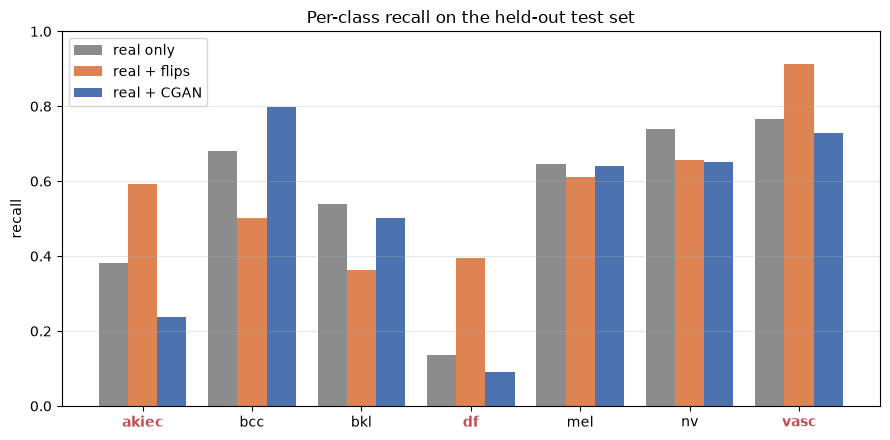

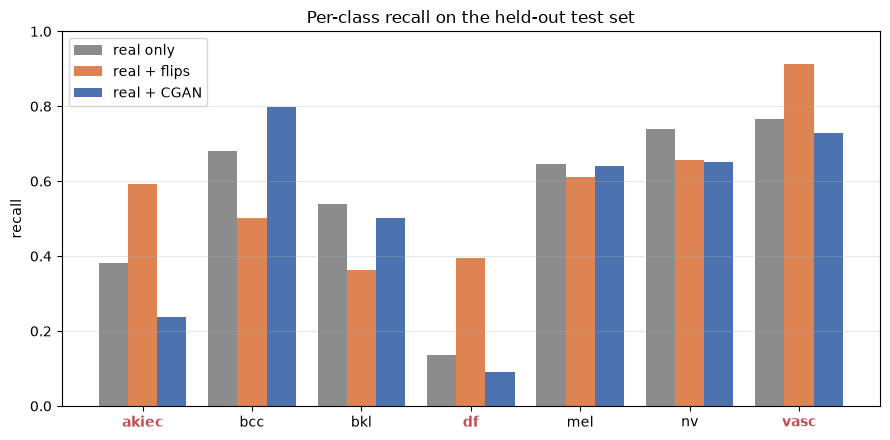

In [15]:
figure = plots.plot_recall_comparison(arms, data.RARE_CLASSES,
                                      save_path=ASSETS / "recall_comparison.png")
figure


Row-normalised confusion matrices, taken from the first seed of each arm. Each row sums to 1,
so the diagonal is that class's recall and the off-diagonal cells show where its images went
instead.


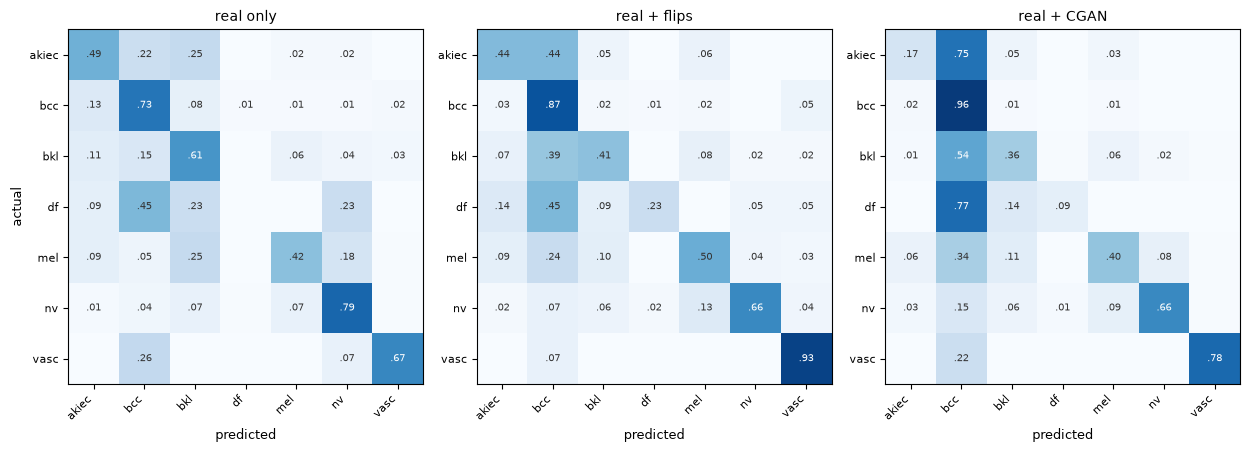

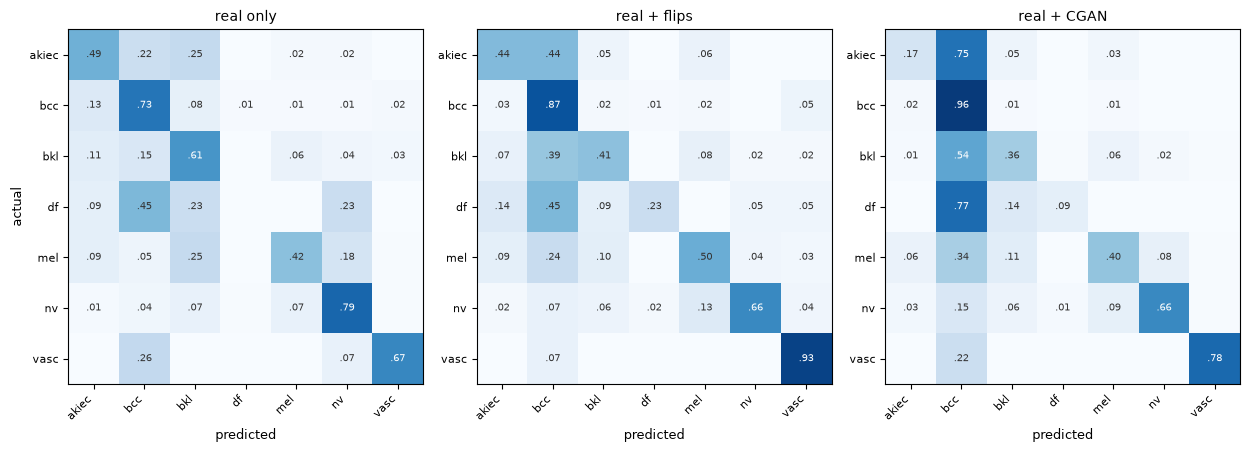

In [16]:
figure = plots.plot_confusion_matrices(arms, y_test, save_path=ASSETS / "confusion_matrices.png")
figure


In [17]:
def rare_recall(result):
    return sum(result["per_class"][i]["recall"] for i in rare_ids) / len(rare_ids)


summary = {
    "images": len(labels),
    "train": len(X_train),
    "test": len(X_test),
    "train_classical": len(X_classical),
    "train_gan": len(X_gan),
    "seeds": list(SEEDS),
    "arms": {
        arm: {
            "accuracy": result["accuracy"],
            "accuracy_spread": result["accuracy_spread"],
            "macro_f1": result["macro_f1"],
            "rare_recall": rare_recall(result),
            "per_class_recall": {
                data.SHORT_NAMES[payload["classes"][i]]: result["per_class"][i]["recall"]
                for i in range(n_classes)
            },
        }
        for arm, result in arms.items()
    },
}

(ASSETS / "results.json").write_text(json.dumps(summary, indent=2))

for arm, result in arms.items():
    print(f"{arm:<13} accuracy {result['accuracy']:.3f}   macro F1 {result['macro_f1']:.3f}   "
          f"mean rare recall {rare_recall(result):.3f}")


real only     accuracy 0.609   macro F1 0.548   mean rare recall 0.428
real + flips  accuracy 0.553   macro F1 0.528   mean rare recall 0.633
real + CGAN   accuracy 0.580   macro F1 0.528   mean rare recall 0.352


## 6. What this shows, and what it does not

**The answer to the question this notebook opened with is no.** Classical augmentation lifts
mean recall on the three rare classes from 0.428 to 0.633. The CGAN arm reaches 0.352 — below
doing nothing at all.

The reason is in the label-fidelity table above, not in the loss curves. For `akiec` (0.04
agreement) and `df` (0.00), almost nothing the generator draws reads as that class to a
classifier trained on real images, and those are exactly the two classes whose recall the CGAN
arm damaged most. The arm trained on hundreds of mislabelled images.

Worth noting what this is *not*: the generator is not broken. Overall label agreement is about
double chance, samples are diverse and lesion-shaped, and `vasc` reaches 0.59 agreement from
only 109 real images. It reproduced the classes whose appearance survives 32x32 and failed on
the subtle textural ones — which happened to be the ones the exercise was for.

**Limitations worth being honest about:**

* **32x32 is far below diagnostic resolution.** These images are training signal, not anything
  a clinician would look at. Resolution was traded for convergence: at 64x64 the same time
  budget gave roughly a tenth of the generator updates and never left the noise stage.
* **Diversity is not realism.** The within-class spread measured here catches mode collapse,
  which is the failure that actually occurred, but a generator can be diverse and still
  unrealistic. FID against a held-out real set would measure the other half.
* **The augmented arms see more gradient steps per epoch**, simply because they hold more
  images. That is inherent to adding data, but it is why the classical arm rather than the
  real-only arm is the meaningful baseline.
* **One configuration is not a verdict on GAN augmentation.** Published work trains far longer
  at higher resolution and reports gains.
* **Nothing here is a medical device.** It is a study of class imbalance, on medical data.

**Reasonable next steps:** higher resolution with a stabilised objective (WGAN-GP), FID for
sample realism, and a comparison against class-weighted loss, which is cheaper than either
augmentation strategy.
